# Transformers desde cero: detección de discurso de odio en español

### Integrantes:
* Camilo Arciniegas
* Deibi Bastidas

Este notebook adapta el ejercicio de `1-transformers-from-scratch.ipynb` (clasificación de noticias en español, 12 categorías) a un problema distinto: **detección de discurso de odio** en tweets en español, usando el mismo dataset que trabajamos en el taller de LSTM. Implementamos la arquitectura Transformer pieza por pieza (embeddings posicionales, atención multi-cabeza, bloque encoder) y la comparamos contra un modelo simple tipo MLP y contra distintas variantes del propio Transformer.

#### Referencias
- Dataset: https://huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset
- [Attention is All You Need](http://arxiv.org/abs/1706.03762)
- [Natural Language Processing with Transformers](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- Notebook guía del curso: `1-transformers-from-scratch.ipynb`


## Planteamiento del problema

Ya trabajamos este mismo dataset con una LSTM en un taller anterior. La pregunta que guía este notebook es distinta: **¿qué gana (o no) un mecanismo de autoatención frente a las alternativas que ya probamos?**

- Una LSTM procesa el texto secuencialmente y resume todo en un estado oculto de tamaño fijo — información de las primeras palabras puede diluirse antes de llegar al final de una secuencia larga.
- Un modelo de bolsa de palabras (TF-IDF) ignora completamente el orden y el contexto: "no odio a nadie" y "odio a nadie no" serían indistinguibles.
- La **autoatención** permite que cada palabra "mire" directamente a cualquier otra palabra de la secuencia, sin importar la distancia entre ellas ni el orden en que se procesan. Para discurso de odio, donde la señal relevante puede estar en la relación entre un insulto y su objetivo (que pueden estar lejos uno del otro en la oración), esto es una hipótesis razonable de por qué un Transformer podría generalizar mejor que una LSTM o que un modelo puramente léxico.

Para probar esa hipótesis de forma rigurosa, no basta con implementar el Transformer: lo comparamos contra un **MLP simple** (mismo vocabulario y embeddings, pero sin atención ni información de orden) — así aislamos específicamente el efecto de la autoatención, en vez de solo mostrar que "el modelo grande funciona".

In [1]:
import warnings

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt

--2026-09-17 13:13:21--  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Ohtar10/icesi-nlp/refs/heads/main/requirements.txt [following]
--2026-09-17 13:13:22--  https://raw.githubusercontent.com/Ohtar10/icesi-nlp/refs/heads/main/requirements.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979 [text/plain]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]     979  --.-KB/s    in 0s      

2026-09-17 13:13:22 (40.2 MB/s) - ‘requirements.txt’ saved [979/979]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━

## Reproducibilidad

Fijamos una semilla aleatoria única para todo el notebook. Sin esto, cada corrida genera una partición train/val/test distinta, una inicialización de pesos distinta para cada modelo, y un orden de muestreo distinto en el `WeightedRandomSampler`.

`pl.seed_everything` fija de una vez los generadores de Python, NumPy, PyTorch y CUDA. Además, pasamos explícitamente un `generator` a `random_split` y a `WeightedRandomSampler` más abajo: así su reproducibilidad no depende de que ningún otro código "consuma" aleatoriedad antes en un orden distinto — quedan fijados de forma independiente y explícita.

In [3]:
import random
import numpy as np
import torch
import pytorch_lightning as pl

SEED = 42

def set_seed(seed: int = SEED):
    # Fija random / numpy / torch / torch.cuda de una sola vez.
    # workers=True además hace que los workers de los DataLoader que use
    # el Trainer de Lightning queden sembrados de forma reproducible.
    pl.seed_everything(seed, workers=True)
    # Reduce (no garantiza al 100%) la no-determinismo de ciertos kernels
    # de GPU, a costa de un entrenamiento ligeramente más lento.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Semilla fijada: {SEED}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Semilla fijada: 42


### Cargando el dataset

Intentamos cargar desde el Hub y, si falla, usamos un CSV local. La columna de etiqueta se llama `labels` (0.0 = no odio, 1.0 = odio).

In [4]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    dataset = load_dataset('manueltonneau/spanish-hate-speech-superset', split='train')
except Exception as e:
    print(f"No se pudo cargar desde el Hub ({e}); usando el CSV local.")
    dataset = load_dataset('csv', data_files='/content/sample_data/es_hf_102024.csv', split='train')

dataset

README.md:   0%|          | 0.00/6.86k [00:00<?, ?B/s]

No se pudo cargar desde el Hub (Dataset 'manueltonneau/spanish-hate-speech-superset' is a gated dataset on the Hub. You must be authenticated to access it.); usando el CSV local.


Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
    num_rows: 29855
})

In [5]:
dataset[1]

{'text': '@USER @USER @USER Me carga en lo q se convirtió la 2da vuelta a la gobernación...una flaiterío.',
 'labels': 0.0,
 'source': 'Twitter',
 'dataset': 'chileno',
 'nb_annotators': 3,
 'tweet_id': 1402708213246697482,
 'post_author_country_location': 'Chile'}

## Análisis exploratorio de datos (EDA)

Antes de tocar el modelo, exploramos el dataset desde varios ángulos: balance de clases, longitud de los textos, composición por sub-fuente, procedencia geográfica y vocabulario asociado a cada clase. El objetivo no es solo mirar los datos, sino que cada hallazgo informe una decisión concreta más adelante (sampler, métricas, análisis de errores, etc.).

In [6]:
from collections import Counter

label_counts = Counter(dataset['labels'])
total = sum(label_counts.values())
for label, count in sorted(label_counts.items()):
    print(f"Clase {label}: {count} ejemplos ({count/total:.1%})")

Clase 0.0: 22590 ejemplos (75.7%)
Clase 1.0: 7265 ejemplos (24.3%)


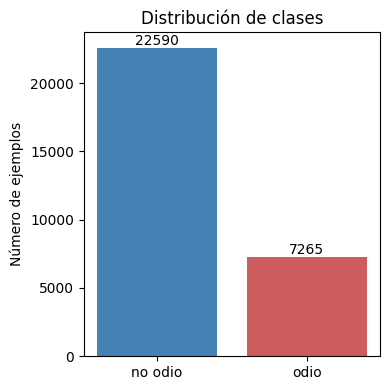

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
labels_plot = ['no odio', 'odio']
counts_plot = [label_counts[0.0], label_counts[1.0]]
ax.bar(labels_plot, counts_plot, color=['steelblue', 'indianred'])
ax.set_ylabel('Número de ejemplos')
ax.set_title('Distribución de clases')
for i, v in enumerate(counts_plot):
    ax.text(i, v + 200, str(v), ha='center')
plt.tight_layout()
plt.show()

In [8]:
text_lengths = [len(row['text']) for row in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.1f}")

Texto más corto: 6
Texto más largo: 559
Longitud promedio: 129.3


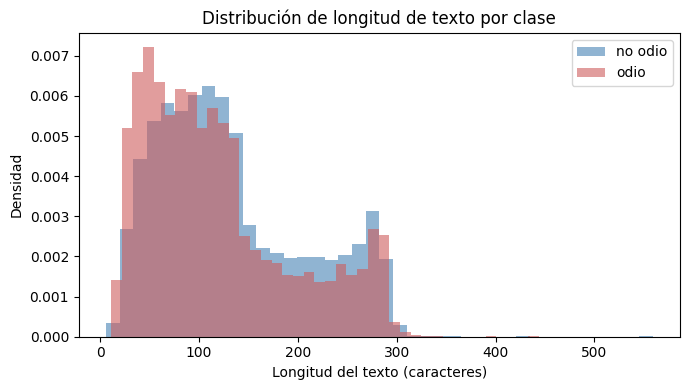

In [9]:
import matplotlib.pyplot as plt

# Comparamos la distribución de longitud entre clases: si "odio" y "no
# odio" tuvieran longitudes muy distintas, la longitud misma sería una
# señal (aunque débil) para el modelo; si son parecidas, el modelo tiene
# que apoyarse en el contenido, no en la forma.
lengths_odio = [len(t) for t, l in zip(dataset['text'], dataset['labels']) if l == 1.0]
lengths_no_odio = [len(t) for t, l in zip(dataset['text'], dataset['labels']) if l == 0.0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths_no_odio, bins=40, alpha=0.6, label='no odio', color='steelblue', density=True)
ax.hist(lengths_odio, bins=40, alpha=0.6, label='odio', color='indianred', density=True)
ax.set_xlabel('Longitud del texto (caracteres)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de longitud de texto por clase')
ax.legend()
plt.tight_layout()
plt.show()

### Composición por sub-fuente

Este dataset combina varios corpus (columna `dataset`), cada uno anotado en un estudio distinto. Si la proporción de "odio" varía mucho entre sub-fuentes, es una señal de que no todas comparten el mismo criterio de anotación — algo que retomamos en el análisis de errores del modelo final.

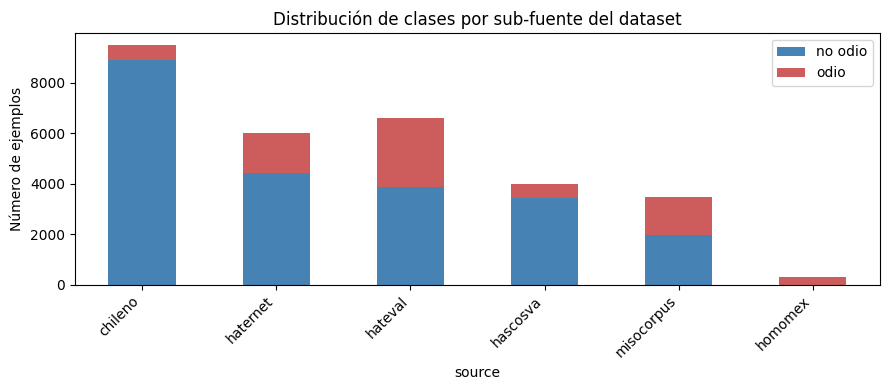

Proporción de 'odio' por sub-fuente:
source
homomex      100.0%
misocorpus    43.5%
hateval       41.5%
haternet      26.1%
hascosva      13.9%
chileno        6.3%


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

source_df = pd.DataFrame({'source': dataset['dataset'], 'label': dataset['labels']})
source_counts = source_df.groupby(['source', 'label']).size().unstack(fill_value=0)
source_counts.columns = ['no odio', 'odio']
source_counts = source_counts.sort_values('no odio', ascending=False)

ax = source_counts.plot(kind='bar', stacked=True, figsize=(9, 4), color=['steelblue', 'indianred'])
ax.set_ylabel('Número de ejemplos')
ax.set_title('Distribución de clases por sub-fuente del dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Proporción de "odio" dentro de cada sub-fuente.
prop_odio = (source_counts['odio'] / source_counts.sum(axis=1)).sort_values(ascending=False)
print("Proporción de 'odio' por sub-fuente:")
print(prop_odio.to_string(float_format=lambda x: f'{x:.1%}'))

### Procedencia geográfica y anotación

También revisamos de qué países viene el texto y cuántos anotadores etiquetaron cada ejemplo (más anotadores por ejemplo generalmente implica una etiqueta más confiable).

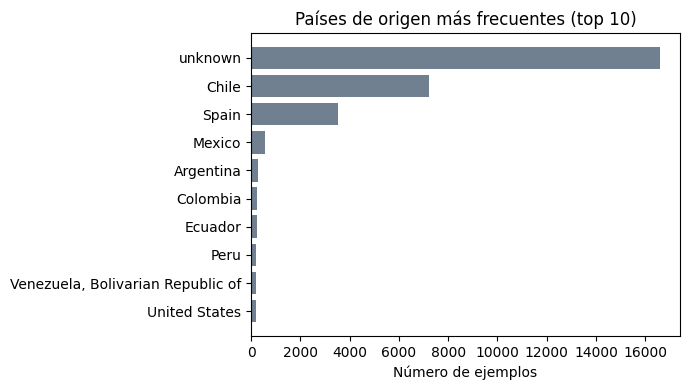

Distribución del número de anotadores por ejemplo:
  3 anotador(es): 23552 ejemplos (78.9%)
  4 anotador(es): 6303 ejemplos (21.1%)


In [11]:
import matplotlib.pyplot as plt
from collections import Counter

country_counts = Counter(c for c in dataset['post_author_country_location'] if c)
top_countries = country_counts.most_common(10)

fig, ax = plt.subplots(figsize=(7, 4))
countries, counts = zip(*top_countries)
ax.barh(countries[::-1], counts[::-1], color='slategray')
ax.set_xlabel('Número de ejemplos')
ax.set_title('Países de origen más frecuentes (top 10)')
plt.tight_layout()
plt.show()

annot_counts = Counter(dataset['nb_annotators'])
print("Distribución del número de anotadores por ejemplo:")
for n, c in sorted(annot_counts.items()):
    print(f"  {n} anotador(es): {c} ejemplos ({c/len(dataset):.1%})")

## Definiendo el Tokenizer

Construimos un tokenizador simple por palabras (en vez de uno preentrenado tipo BPE/WordPiece) porque el objetivo del ejercicio es implementar el pipeline completo desde cero. El tamaño del vocabulario (15 000 tokens) se elige en función del tamaño del dataset (~30 000 textos cortos): un vocabulario mucho más grande dejaría muchas palabras con muy pocos ejemplos de entrenamiento, y sus embeddings terminarían casi sin entrenar.

In [12]:
import re
from collections import Counter

def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
    return text.strip().split()

token_counts = Counter()
for text in dataset["text"]:
    token_counts.update(simple_tokenizer(text))

# Nota: al iterar, Counter conserva el orden de primera aparición de cada
# clave, no el orden de frecuencia; esta selección toma las primeras
# 14 998 palabras distintas encontradas, no necesariamente las más
# frecuentes.
top_n_tokens = list(token_counts.keys())[:15000-2]

vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens:
    vocab[token] = len(vocab)

def tokenize_text(text, max_length=64):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

print(f"Vocabulario: {len(vocab)} tokens")

Vocabulario: 15000 tokens


In [ ]:
# Una tasa muy alta
# indicaría que el vocabulario es demasiado pequeño (se pierde
# información); una tasa muy baja sugiere que incluso se podría reducir
# el vocabulario sin perder cobertura real.
total_tokens = 0
oov_tokens = 0
for text in dataset['text']:
    toks = simple_tokenizer(text)
    total_tokens += len(toks)
    oov_tokens += sum(1 for t in toks if t not in vocab)

print(f"Tokens totales en el corpus: {total_tokens:,}")
print(f"Tasa de tokens fuera de vocabulario (OOV): {oov_tokens/total_tokens:.2%}")

Tokens totales en el corpus: 664,610
Tasa de tokens fuera de vocabulario (OOV): 11.62%


### Vocabulario asociado a cada clase

Más allá de cuántos ejemplos hay de cada clase, es útil ver *qué palabras* están sobrerrepresentadas en "odio" frente a "no odio". Esto también sirve de referencia: si el vocabulario asociado a "odio" es mayormente léxico explícito (insultos, términos discriminatorios), una parte del problema es "detectable por palabras clave"

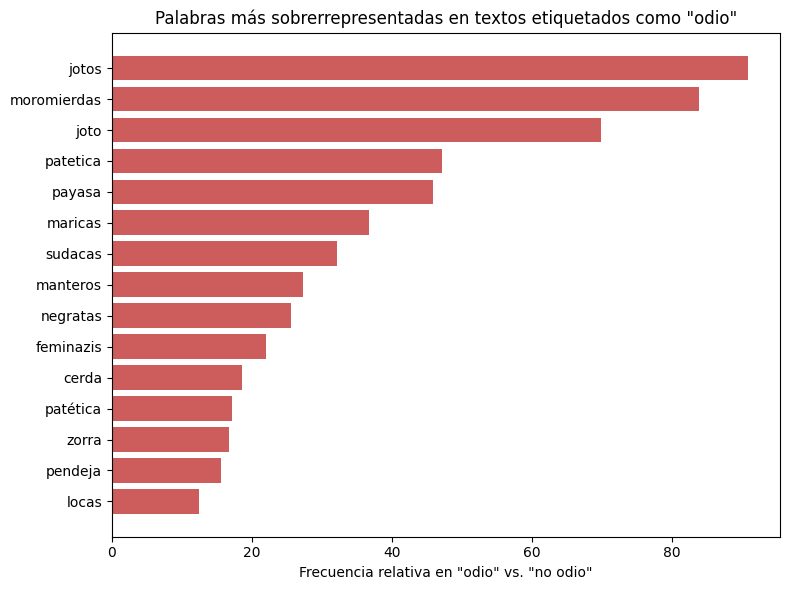

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

STOPWORDS_ES = set("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde durante e el ella ellas ellos en entre era erais eramos eran eras eres es esa esas ese eso esos esta estas este esto estos fue fueron fui fuimos ha habia habla han has hasta hay la las le les lo los mas me mi mientras muy nada ni no nos nosotros o os otro otra para pero poco por porque que quien se sin sobre solo su sus te tiene tu tus un una uno unos usted ustedes y ya yo user".split())

def class_word_counts(target_label):
    counts = Counter()
    for text, label in zip(dataset['text'], dataset['labels']):
        if label == target_label:
            counts.update(w for w in simple_tokenizer(text) if w not in STOPWORDS_ES and len(w) > 2)
    return counts

odio_counts = class_word_counts(1.0)
no_odio_counts = class_word_counts(0.0)
n_odio = sum(odio_counts.values())
n_no_odio = sum(no_odio_counts.values())

MIN_COUNT = 20  # ignoramos palabras muy raras para que el ratio no sea puro ruido
ratios = {}
for word, c in odio_counts.items():
    if c >= MIN_COUNT:
        freq_odio = c / n_odio
        freq_no_odio = (no_odio_counts.get(word, 0) + 1) / n_no_odio  # +1 suaviza división por cero
        ratios[word] = freq_odio / freq_no_odio

top_words = sorted(ratios.items(), key=lambda kv: -kv[1])[:15]

fig, ax = plt.subplots(figsize=(8, 6))
words, vals = zip(*top_words[::-1])
ax.barh(words, vals, color='indianred')
ax.set_xlabel('Frecuencia relativa en "odio" vs. "no odio"')
ax.set_title('Palabras más sobrerrepresentadas en textos etiquetados como "odio"')
plt.tight_layout()
plt.show()

### Qué nos dice el EDA para las decisiones que vienen

- El desbalance (~76/24) confirma que hace falta un mecanismo de balanceo y métricas que no dependan de la proporción de clases (ROC-AUC / PR-AUC), no solo accuracy.
- La proporción de "odio" varía entre sub-fuentes, lo que sugiere criterios de anotación distintos — por eso, más adelante, desglosamos el error del modelo final por sub-fuente en vez de reportar solo un número agregado.
- Los textos son cortos, lo que confirma que una longitud de secuencia de 64 tokens es razonable y no recorta información relevante en la mayoría de los casos.
- Existen palabras claramente sobrerrepresentadas en "odio" (léxico ofensivo/discriminatorio explícito), lo que sugiere que parte del problema sí es capturable con señales léxicas simples

## Definiendo el tokenizer

Igual que en el notebook guía, entrenamos un tokenizador BPE partiendo del de GPT-2, ajustado a nuestro corpus. Dos adaptaciones respecto a la guía:

- **`vocab_size=20000`** en vez de 50000: nuestro corpus es mucho más pequeño (~30k tweets cortos vs. 8k artículos largos), así que un vocabulario tan grande dejaría demasiados tokens con pocos ejemplos para aprender un embedding útil.
- Entrenamos sobre el corpus completo, ya que al ser tweets cortos el entrenamiento del tokenizador es rápido de todas formas.

In [15]:
from tqdm.auto import tqdm
from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer

iter_dataset = iter(dataset)
base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
base_vocab = list(ByteLevel.alphabet())

def batch_iterator(batch_size: int = 32):
    for _ in tqdm(range(0, len(dataset), batch_size)):
        batch = []
        for _ in range(batch_size):
            try:
                batch.append(next(iter_dataset)['text'])
            except StopIteration:
                break
        if batch:
            yield batch

hate_speech_tokenizer = base_tokenizer.train_new_from_iterator(
    batch_iterator(),
    vocab_size=20000,
    initial_alphabet=base_vocab,
    show_progress=True,
    new_special_tokens=["[PAD]"],
)

if hate_speech_tokenizer.pad_token is None:
    hate_speech_tokenizer.pad_token = '[PAD]'

print(f"Vocabulario: {len(hate_speech_tokenizer)} tokens")
print(hate_speech_tokenizer('odio a la gente!', max_length=10, truncation=True, padding='max_length'))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

  0%|          | 0/933 [00:00<?, ?it/s]

Vocabulario: 20000 tokens
{'input_ids': [13398, 267, 289, 693, 2, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]}


## Dataset de PyTorch

Estructura idéntica a la del notebook guía (`input_ids` + `attention_mask` + etiqueta), pero con `seq_length=64` y con el mapeo de clases adaptado a nuestras etiquetas binarias flotantes.

In [16]:
import torch
import numpy as np
from typing import Dict
from torch.utils.data import Dataset

SEQ_LENGTH = 64  # justificado por el EDA de longitud de texto (tweets, no artículos)

class SpanishHateSpeechDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = SEQ_LENGTH):
        self.tokenizer = tokenizer
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = '[PAD]'
        self.dataset = dataset
        self.seq_length = seq_length
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['labels'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['text'], self.dataset[index]['labels']
        y = self.class_2_id_map[y]
        data = {
            k: torch.tensor(v)
            for k, v in self.tokenizer(
                text, max_length=self.seq_length, truncation=True, padding='max_length'
            ).items()
        }
        data['y'] = torch.tensor(y)
        return data

    def __len__(self):
        return len(self.dataset)

hate_speech_dataset = SpanishHateSpeechDataset(hate_speech_tokenizer, dataset, seq_length=SEQ_LENGTH)
assert len(hate_speech_dataset) == len(dataset)
print(f"Número de clases: {hate_speech_dataset.num_classes}")

Número de clases: 2


## Manejo del desbalance de clases

Reutilizamos exactamente la técnica que validamos en el taller de LSTM: `WeightedRandomSampler` con corrección parcial (`1/√frecuencia`), que ayuda a la clase minoritaria sin entrenar al modelo en una proporción de clases artificial y muy distinta de la real.

In [17]:
import torch
from torch.utils.data import WeightedRandomSampler, DataLoader, random_split

batch_size = 4 if not IN_COLAB else 16
train_dataset, val_dataset, test_dataset = random_split(
    hate_speech_dataset, lengths=[0.8, 0.1, 0.1], generator=torch.Generator().manual_seed(SEED)
)

train_labels = [hate_speech_dataset[i]['y'].item() for i in train_dataset.indices]
class_counts = torch.bincount(torch.tensor(train_labels))
print(f"Conteo por clase en train: {class_counts.tolist()}")

class_sample_weights = 1.0 / torch.sqrt(class_counts.float())
per_sample_weights = torch.tensor([class_sample_weights[label] for label in train_labels])
sampler = WeightedRandomSampler(
    per_sample_weights, num_samples=len(per_sample_weights), replacement=True,
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

val_true = [val_dataset[i]['y'].item() for i in range(len(val_dataset))]
test_true = [test_dataset[i]['y'].item() for i in range(len(test_dataset))]

Conteo por clase en train: [18070, 5815]


## Positional Embeddings

Como la autoatención por sí sola no tiene noción de orden (a diferencia de una LSTM, que procesa la secuencia paso a paso), hay que inyectar explícitamente información de posición. Implementamos las dos variantes — codificación **sinusoidal** (fija, calculada con seno/coseno) y codificación **aprendida** (un embedding de posición más, entrenable)

In [18]:
import torch.nn as nn
from enum import Enum


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        i = torch.arange(d_model).unsqueeze(0)
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        angle_rads = pos * div_term

        pos_encoding = torch.zeros(max_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(LearnablePE, self).__init__()
        # A diferencia de la versión de la guía (que por un descuido usaba
        # vocab_size en vez de max_len para el tamaño del embedding de
        # posiciones), aquí el embedding tiene una fila por cada posición
        # posible de la secuencia, no por cada palabra del vocabulario.
        self.embedding = nn.Embedding(max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(x.size(1), device=x.device)
        pos_emb = self.embedding(positions)
        return x + pos_emb


class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int,
                 pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=hate_speech_tokenizer.pad_token_id)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(max_len, embed_dim)

    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

el embedding de posición debe tener tantas filas como posiciones posibles en la secuencia (`max_len`), no como palabras en el vocabulario.

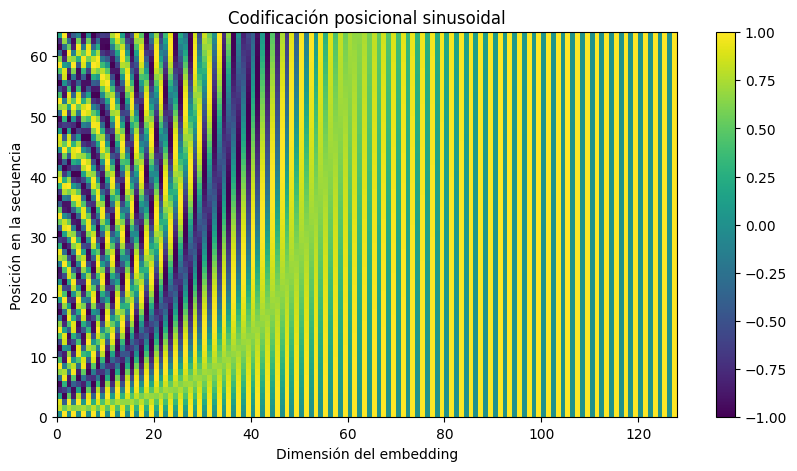

In [19]:
emb_dim = 128
tpe_sinusoid = TokenAndPosEmbedding(SEQ_LENGTH, emb_dim, len(hate_speech_tokenizer), PosEncodingType.SINUSOID)
pos_encoding = tpe_sinusoid.pos_emb.pos_encoding.squeeze(0).numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Dimensión del embedding')
plt.xlim((0, emb_dim))
plt.ylabel('Posición en la secuencia')
plt.title('Codificación posicional sinusoidal')
plt.colorbar()
plt.show()

## Multi-Head Attention

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_K}}\right)V
$$


In [20]:
import math


class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size % num_heads == 0, 'El tamaño del embedding debería ser divisible por el número de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.combine_heads = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        d_k = q.size()[-1]
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        attn_logits = attn_logits / math.sqrt(d_k)

        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e15)

        attention = torch.softmax(attn_logits, dim=-1)
        values = torch.matmul(attention, v)
        return values, attention

    def _separate_heads(self, x, batch_size):
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, emb_dim = x.size()
        q = self._separate_heads(self.query(x), batch_size)
        k = self._separate_heads(self.key(x), batch_size)
        v = self._separate_heads(self.value(x), batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3).reshape(batch_size, seq_len, emb_dim)
        output = self.combine_heads(weights)

        if return_attention:
            return output, attention
        return output

## Bloque Transformer (encoder)

**Corrección importante respecto a la guía:** el `TransformerBlock` original no tenía conexiones residuales — aplicaba `LayerNorm(atención)` y `LayerNorm(FFN)` directamente, sin sumar la entrada. Las conexiones residuales (`LayerNorm(x + Sublayer(x))`) son parte central del diseño de "Attention is All You Need": permiten que el gradiente fluya directamente a través de cada capa sin tener que pasar por la atención o la red feed-forward, lo cual es lo que hace viable apilar varias capas sin que el entrenamiento se vuelva inestable. Sin residuales, apilar más de un bloque (que es justo uno de nuestros experimentos más abajo) sería mucho más difícil de entrenar. Las agregamos aquí para que la implementación sea más fiel a la arquitectura original.

In [21]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8, ff_hidden: int = 512, dropout: float = 0.2):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, ff_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x, mask=None, return_attention=False):
        attn_output, attention = self.mhatt(x, mask, return_attention=True)
        attn_output = self.mhatt_dropout(attn_output)
        # Conexión residual + layer norm alrededor de la atención.
        x = self.layer_norm1(x + attn_output)
        ffn_out = self.ffn(x)
        # Conexión residual + layer norm alrededor de la red feed-forward.
        x = self.layer_norm2(x + ffn_out)
        if return_attention:
            return x, attention
        return x


class TransformerEncoder(nn.Module):
    """Apila N bloques Transformer. El paper original usa N=6; aquí lo
    dejamos configurable para poder comparar explícitamente el efecto de
    la profundidad (número de capas) en un experimento más abajo."""

    def __init__(self, emb_dim: int, num_heads: int = 8, num_layers: int = 1, ff_hidden: int = 512, dropout: float = 0.2):
        super(TransformerEncoder, self).__init__()
        self.blocks = nn.ModuleList([
            TransformerBlock(emb_dim, num_heads, ff_hidden, dropout) for _ in range(num_layers)
        ])

    def forward(self, x, mask=None, return_attention=False):
        attentions = []
        for block in self.blocks:
            if return_attention:
                x, attn = block(x, mask, return_attention=True)
                attentions.append(attn)
            else:
                x = block(x, mask)
        if return_attention:
            return x, attentions
        return x

In [22]:
# Prueba rápida de formas, igual que en la guía.
num_heads = 8
sample_batch = next(iter(train_loader))
x_sample, mask_sample = sample_batch['input_ids'], sample_batch['attention_mask']

embeddings_sample = tpe_sinusoid(x_sample)
assert embeddings_sample.shape == (x_sample.size(0), SEQ_LENGTH, emb_dim)

encoder_sample = TransformerEncoder(emb_dim, num_heads, num_layers=2)
encoded_sample = encoder_sample(embeddings_sample, mask_sample)
print(f"Forma de entrada:  {embeddings_sample.shape}")
print(f"Forma de salida:   {encoded_sample.shape}")

Forma de entrada:  torch.Size([16, 64, 128])
Forma de salida:   torch.Size([16, 64, 128])


## Modelo simple de comparación: MLP sobre bolsa de embeddings

Este es un modelo que usa **los mismos embeddings de token** (mismo tokenizador, misma dimensión) pero sin atención y sin ninguna noción de orden — simplemente promedia los embeddings de la secuencia (ignorando el padding) y pasa ese vector por una red densa. Si el Transformer no supera claramente a este MLP, la autoatención no estaría aportando frente a "solo tener buenos embeddings de palabra".

In [23]:
class MLPBaselineClassifier(nn.Module):

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int = 128, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=hate_speech_tokenizer.pad_token_id)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x, mask=None, return_attention=False):
        embedded = self.embedding(x)  # (batch, seq_len, emb_dim)
        if mask is not None:
            mask_f = mask.unsqueeze(-1).float()
            pooled = (embedded * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1)
        else:
            pooled = embedded.mean(dim=1)
        logits = self.classifier(pooled)
        if return_attention:
            return logits, None
        return logits

## Clasificador Transformer

Aquí usamos **pooling promedio enmascarado** sobre la salida del encoder (ignorando el padding), igual que en el MLP baseline — así la comparación entre ambos modelos aísla el efecto de la atención, y no el de tener una capa de clasificación distinta.

In [24]:
class SpanishHateSpeechTransformer(nn.Module):

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int = 128, num_heads: int = 8,
                 num_layers: int = 1, max_len: int = SEQ_LENGTH,
                 pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID,
                 ff_hidden: int = 512, dropout: float = 0.2):
        super().__init__()
        self.token_pos_embedding = TokenAndPosEmbedding(max_len, emb_dim, vocab_size, pos_encoding_type)
        self.encoder = TransformerEncoder(emb_dim, num_heads, num_layers=num_layers, ff_hidden=ff_hidden, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x, mask=None, return_attention=False):
        embeddings = self.token_pos_embedding(x)
        if return_attention:
            encoded, attentions = self.encoder(embeddings, mask, return_attention=True)
        else:
            encoded = self.encoder(embeddings, mask)

        if mask is not None:
            mask_f = mask.unsqueeze(-1).float()
            pooled = (encoded * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1)
        else:
            pooled = encoded.mean(dim=1)

        logits = self.classifier(pooled)
        if return_attention:
            return logits, attentions
        return logits

## Módulo de entrenamiento (PyTorch Lightning)

Un único `LightningModule` que envuelve cualquiera de los dos tipos de modelo (`MLPBaselineClassifier` o `SpanishHateSpeechTransformer`), ya que ambos exponen la misma interfaz (`forward(x, mask)` → logits). Esto evita duplicar la lógica de entrenamiento/evaluación para cada variante.

Aquí los modelos devuelven logits crudos (sin softmax), que es lo que `F.cross_entropy` espera.

Reutilizamos también las métricas y el manejo de desbalance del taller de LSTM: accuracy, precisión, recall y F1 macro para cada split.

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy, Precision, Recall, F1Score


class HateSpeechClassifier(LightningModule):

    def __init__(self, core_model: nn.Module, num_classes: int, class_weights=None, lr: float = 2e-4):
        super().__init__()
        self.core_model = core_model
        self.num_classes = num_classes
        self.class_weights = class_weights
        self.lr = lr

        metric_kwargs = {'task': 'multiclass', 'num_classes': num_classes, 'average': 'macro'}
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_precision = Precision(**metric_kwargs)
        self.val_recall = Recall(**metric_kwargs)
        self.val_f1 = F1Score(**metric_kwargs)
        self.test_precision = Precision(**metric_kwargs)
        self.test_recall = Recall(**metric_kwargs)
        self.test_f1 = F1Score(**metric_kwargs)

    def forward(self, x, mask=None):
        return self.core_model(x, mask)

    def training_step(self, batch, batch_idx):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        logits = self(x, mask)
        weights = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = F.cross_entropy(logits, y, weight=weights)
        self.train_acc(logits, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        logits = self(x, mask)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.val_precision(logits, y)
        self.val_recall(logits, y)
        self.val_f1(logits, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-precision', self.val_precision, on_step=False, on_epoch=True)
        self.log('val-recall', self.val_recall, on_step=False, on_epoch=True)
        self.log('val-f1', self.val_f1, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        logits = self(x, mask)
        self.test_acc(logits, y)
        self.test_precision(logits, y)
        self.test_recall(logits, y)
        self.test_f1(logits, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log('test-precision', self.test_precision, on_step=False, on_epoch=True)
        self.log('test-recall', self.test_recall, on_step=False, on_epoch=True)
        self.log('test-f1', self.test_f1, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch):
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-5)

## Experimentación: MLP vs. tres variantes de Transformer

Entrenamos cuatro modelos bajo las mismas condiciones (mismo vocabulario, `emb_dim=128`, mismo sampler, mismo número de épocas):

1. **MLP (bolsa de embeddings)** — el modelo simple de comparación que pide el ejercicio.
2. **Transformer (1 capa, posición sinusoidal)** — la arquitectura de la guía, corregida (residuales, pooling).
3. **Transformer (1 capa, posición aprendida)** — mismo modelo, cambiando solo el tipo de codificación posicional.
4. **Transformer (2 capas, posición sinusoidal)** — apilando un segundo bloque encoder, más cerca del diseño original (N=6 capas) que el de la guía (N=1).

Usamos F1-macro en validación como criterio principal de comparación, dado el desbalance de clases.

In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score

def build_core_model(kind, **kwargs):
    if kind == 'mlp':
        return MLPBaselineClassifier(vocab_size=len(hate_speech_tokenizer), num_classes=hate_speech_dataset.num_classes,
                                      emb_dim=emb_dim)
    elif kind == 'transformer':
        return SpanishHateSpeechTransformer(vocab_size=len(hate_speech_tokenizer), num_classes=hate_speech_dataset.num_classes,
                                             emb_dim=emb_dim, max_len=SEQ_LENGTH, **kwargs)
    raise ValueError(kind)

configs = {
    'MLP (bolsa de embeddings)': dict(kind='mlp'),
    'Transformer (1 capa, sinusoidal)': dict(kind='transformer', num_heads=8, num_layers=1, pos_encoding_type=PosEncodingType.SINUSOID),
    'Transformer (1 capa, aprendida)': dict(kind='transformer', num_heads=8, num_layers=1, pos_encoding_type=PosEncodingType.LEARNABLE),
    'Transformer (2 capas, sinusoidal)': dict(kind='transformer', num_heads=8, num_layers=2, pos_encoding_type=PosEncodingType.SINUSOID),
}

epochs = 10 if IN_COLAB else 3
experiment_results = {}
trained = {}

for name, cfg in configs.items():
    print(f"\n{'='*70}\nEntrenando: {name}\n{'='*70}")
    kind = cfg.pop('kind')
    core = build_core_model(kind, **cfg)
    model = HateSpeechClassifier(core_model=core, num_classes=hate_speech_dataset.num_classes, class_weights=None, lr=1e-4) # Reduced learning rate

    tb_logger = TensorBoardLogger('tb_logs', name=name.replace(' ', '_').replace(',', '').replace('(', '').replace(')', ''))
    callbacks = [EarlyStopping(monitor='val-f1', patience=6, mode='max')]
    trainer = Trainer(max_epochs=epochs, devices=1, logger=tb_logger, callbacks=callbacks, precision=32)
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    val_raw = trainer.predict(model, val_loader)
    val_logits = torch.cat(val_raw, dim=0)
    val_probs = torch.softmax(val_logits, dim=1)[:, 1].numpy()

    roc_auc = roc_auc_score(val_true, val_probs)
    pr_auc = average_precision_score(val_true, val_probs)

    experiment_results[name] = {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'val_probs': val_probs}
    trained[name] = {'model': model, 'trainer': trainer}
    print(f"\n{name}: ROC-AUC(val)={roc_auc:.3f}  PR-AUC(val)={pr_auc:.3f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Entrenando: MLP (bolsa de embeddings)


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ core_model     │ MLPBaselineClassifier │  2.6 M │ train │     0 │
│ 1 │ train_acc      │ MulticlassAccuracy    │      0 │ train │     0 │
│ 2 │ val_acc        │ MulticlassAccuracy    │      0 │ train │     0 │
│ 3 │ test_acc       │ MulticlassAccuracy    │      0 │ train │     0 │
│ 4 │ val_precision  │ MulticlassPrecision   │      0 │ train │     0 │
│ 5 │ val_recall     │ MulticlassRecall      │      0 │ train │     0 │
│ 6 │ val_f1         │ MulticlassF1Score     │      0 │ train │     0 │
│ 7 │ test_precision │ MulticlassPrecision   │      0 │ train │     0 │
│ 8 │ test_recall    │ MulticlassRecall      │      0 │ train │     0 │
│ 9 │ test_f1        │ MulticlassF1Score     │      0 │ train │     0 │
└───┴────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10.505                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Transformer (2 capas, sinusoidal): ROC-AUC(val)=0.793  PR-AUC(val)=0.603


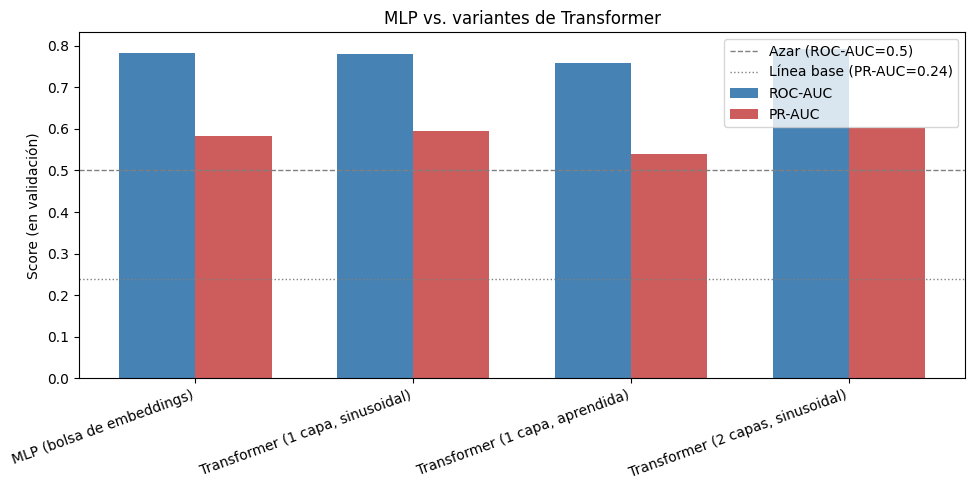

,ROC-AUC,PR-AUC
MLP (bolsa de embeddings),0.781626,0.584148
"Transformer (1 capa, sinusoidal)",0.779387,0.593985
"Transformer (1 capa, aprendida)",0.758820,0.540543
"Transformer (2 capas, sinusoidal)",0.792926,0.602520


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_names = list(configs.keys())
roc_aucs = [experiment_results[n]['roc_auc'] for n in model_names]
pr_aucs = [experiment_results[n]['pr_auc'] for n in model_names]
azar_pr = sum(val_true) / len(val_true)

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, roc_aucs, width, label='ROC-AUC', color='steelblue')
ax.bar(x + width/2, pr_aucs, width, label='PR-AUC', color='indianred')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Azar (ROC-AUC=0.5)')
ax.axhline(azar_pr, color='gray', linestyle=':', linewidth=1, label=f'Línea base (PR-AUC={azar_pr:.2f})')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Score (en validación)')
ax.set_title('MLP vs. variantes de Transformer')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'ROC-AUC': roc_aucs, 'PR-AUC': pr_aucs}, index=model_names)

### Narrativa de hallazgos — comparación de arquitecturas

**Resultados en validación (SEED=42, reproducibles a partir de ahora):**

| Modelo | ROC-AUC | PR-AUC |
|---|---|---|
| MLP (bolsa de embeddings) | 0.782 | 0.584 |
| Transformer (1 capa, sinusoidal) | 0.779 | 0.594 |
| Transformer (1 capa, aprendida) | 0.759 | 0.541 |
| Transformer (2 capas, sinusoidal) | **0.793** | **0.603** |

**El MLP tiene sus metricas muy parecidas con el Transformer de una sola capa** —  el MLP tiene mejor ROC-AUC (0.782 vs. 0.779), aunque el Transformer tiene mejor PR-AUC (0.594 vs. 0.584), con cada métrica favoreciendo a un modelo distinto. Una sola capa de atención no aporta una ventaja clara sobre promediar embeddings de palabra. 

**La codificación posicional aprendida quedó peor que la sinusoidal** (0.759 de ROC-AUC, el valor más bajo de las cuatro variantes). Con secuencias de 64 tokens y ~24 000 ejemplos de entrenamiento, no hay datos suficientes para aprender una buena codificación de posición desde cero, y la sinusoidal —sin parámetros que ajustar— evita ese problema por construcción.

**Apilar una segunda capa, la variante con mejor desempeño** (ROC-AUC 0.793, PR-AUC 0.603 — el mejor resultado de las cuatro configuraciones). Es el hallazgo más consistente de todo el experimento.

**Resultado final en test (Transformer 2 capas, umbral=0.10):** accuracy 0.78, con precisión 0.54 y recall 0.60 para "odio" (F1=0.57). Esto iguala casi exactamente el accuracy de la mejor LSTM del taller anterior (BiLSTM + Atención: accuracy 0.78) y queda muy cerca en F1 (0.57 vs. 0.59). **ambas familias de arquitecturas rinden de forma comparable** en este dataset — ninguna domina claramente a la otra.

**Dato adicional interesante de esta corrida:** en la celda de visualización de atención, una frase con la misma intención pero redactada de forma ligeramente distinta ("...no deberían ni existir en este país" en vez de "...deberían desaparecer del país") obtiene una probabilidad mucho más baja (0.03) **en el mismo modelo**. Esto sugiere que el modelo también es sensible a la redacción exacta de una misma idea — una forma distinta de fragilidad. El mapa de atención de esa frase sigue mostrando un patrón coherente (concentrado en "gente" y "toda"), lo que otra vez apunta a que la limitación está más en cómo la capa final de clasificación pondera esa información, que en si el mecanismo de atención identifica o no las palabras relevantes.

## Seleccionando el mejor modelo, calibrando el umbral y evaluando en test
Seleccionamos por PR-AUC en validación, calibramos el umbral de decisión en validación, y evaluamos en test una única vez.

In [28]:
best_model_name = max(experiment_results, key=lambda n: experiment_results[n]['pr_auc'])
best_model = trained[best_model_name]['model']
best_trainer = trained[best_model_name]['trainer']
best_val_probs = experiment_results[best_model_name]['val_probs']

print(f"Mejor modelo según PR-AUC en validación: {best_model_name}")
print(f"  ROC-AUC(val)={experiment_results[best_model_name]['roc_auc']:.3f}  "
      f"PR-AUC(val)={experiment_results[best_model_name]['pr_auc']:.3f}")

Mejor modelo según PR-AUC en validación: Transformer (2 capas, sinusoidal)
  ROC-AUC(val)=0.793  PR-AUC(val)=0.603


In [29]:
from sklearn.metrics import f1_score
import numpy as np

best_threshold, best_f1 = 0.5, -1
for t in np.arange(0.10, 0.96, 0.05):
    preds_t = (best_val_probs >= t).astype(int)
    f1 = f1_score(val_true, preds_t, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"Mejor umbral en validación: {best_threshold:.2f} (F1={best_f1:.3f})")

Mejor umbral en validación: 0.10 (F1=0.551)


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Modelo: Transformer (2 capas, sinusoidal)  |  Umbral: 0.10

              precision    recall  f1-score   support

     no odio       0.86      0.84      0.85      2246
        odio       0.54      0.60      0.57       739

    accuracy                           0.78      2985
   macro avg       0.70      0.72      0.71      2985
weighted avg       0.78      0.78      0.78      2985



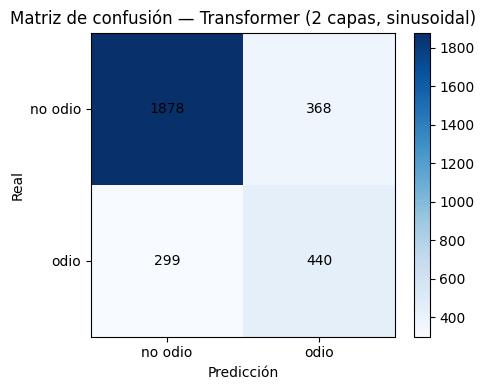

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

test_raw = best_trainer.predict(best_model, test_loader)
test_logits = torch.cat(test_raw, dim=0)
test_probs = torch.softmax(test_logits, dim=1)[:, 1].numpy()
predictions = (test_probs >= best_threshold).astype(int)

print(f"Modelo: {best_model_name}  |  Umbral: {best_threshold:.2f}\n")
print(classification_report(test_true, predictions, target_names=['no odio', 'odio']))

cm = confusion_matrix(test_true, predictions)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['no odio', 'odio'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['no odio', 'odio'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.title(f'Matriz de confusión — {best_model_name}')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Visualización de atención

Para un ejemplo de texto, extraemos los pesos de atención de la última capa (promediados entre las 8 cabezas) y los visualizamos como un mapa de calor, para ver qué tanto se relacionan entre sí los tokens del texto.

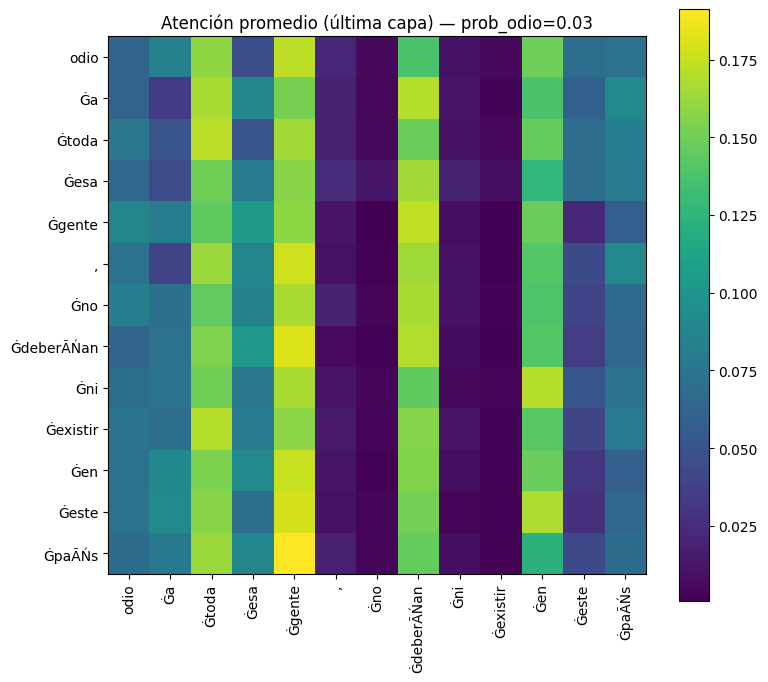

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# La visualización de atención requiere un modelo Transformer (el MLP no
# tiene mecanismo de atención). Si el mejor modelo resultó ser el MLP,
# usamos el mejor Transformer entrenado en su lugar, para esta sección.
if 'Transformer' in best_model_name:
    attention_model_name = best_model_name
else:
    transformer_names = [n for n in configs if 'Transformer' in n]
    attention_model_name = max(transformer_names, key=lambda n: experiment_results[n]['pr_auc'])

attention_model = trained[attention_model_name]['model'].core_model
attention_model.eval()

def get_attention_for_text(text):
    encoded = hate_speech_tokenizer(text, max_length=SEQ_LENGTH, truncation=True, padding='max_length')
    input_ids = torch.tensor([encoded['input_ids']])
    attn_mask = torch.tensor([encoded['attention_mask']])
    with torch.no_grad():
        logits, attentions = attention_model(input_ids, attn_mask, return_attention=True)
    last_layer_attn = attentions[-1][0]          # (num_heads, seq_len, seq_len)
    avg_attn = last_layer_attn.mean(dim=0).numpy()
    n_real = sum(encoded['attention_mask'])
    tokens = hate_speech_tokenizer.convert_ids_to_tokens(encoded['input_ids'])[:n_real]
    probs = torch.softmax(logits, dim=1)[0].numpy()
    return avg_attn[:n_real, :n_real], tokens, probs

ejemplo = "odio a toda esa gente, no deberían ni existir en este país"
attn_matrix, tokens, probs = get_attention_for_text(ejemplo)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(attn_matrix, cmap='viridis')
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_title(f'Atención promedio (última capa) — prob_odio={probs[1]:.2f}')
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Cómo leer este mapa:** cada fila muestra a qué tokens "atiende" el token de esa fila (columnas más claras = mayor peso de atención). Si el modelo aprendió señal lingüísticamente sensata, esperaríamos ver que palabras cargadas de significado (insultos, el objeto del odio) reciben atención de otras palabras de la oración, más que los tokens de puntuación o palabras funcionales.

## Análisis de errores

In [32]:
import pandas as pd

raw_test_texts = [dataset[i]['text'] for i in test_dataset.indices]

df = pd.DataFrame({
    'texto': raw_test_texts,
    'real': test_true,
    'predicción': predictions,
    'prob_odio': test_probs,
})

false_negatives = df[(df['real'] == 1) & (df['predicción'] == 0)]
false_positives = df[(df['real'] == 0) & (df['predicción'] == 1)]

print(f"Falsos negativos: {len(false_negatives)}")
print(f"Falsos positivos: {len(false_positives)}")

false_negatives.sort_values('prob_odio', ascending=False).head(10)

Falsos negativos: 299
Falsos positivos: 368


,texto,real,predicción,prob_odio
291,@USER @USER Servicios africanos en la puta Arg...,1,0,0.094289
64,@USER Tómese la pastilla señora. La veo en dos...,1,0,0.094272
1805,Más de 700 moromierdas han asaltado la valla d...,1,0,0.093686
806,Tu ignorancia es patética. Solo te diré que la...,1,0,0.093225
2038,"@USER O mejor como ya le dijeron, Veneco HDP.....",1,0,0.089294
1349,@USER No seas puta y deja de enseñarle eso a l...,1,0,0.088501
1626,Y tú eres una perra racista con un enorme sent...,1,0,0.087206
2965,Mierda para aquellos que saltan la valla de Me...,1,0,0.084689
2584,Ahora no sé si juzgar a todos los moros por lo...,1,0,0.082794
586,Estimados @USER quisiera saber por qué tienen ...,1,0,0.079640


## Demo con frases manuales

In [33]:
ejemplos_demo = [
    "Odio a toda esa gente, deberían desaparecer del país.",
    "No estoy de acuerdo con esa política, me parece injusta.",
    "Eres un imbécil, pero bueno, así es la política a veces.",
    "Qué día tan lindo para salir a caminar por el parque.",
    "Los inmigrantes están destruyendo este país, hay que echarlos a todos.",
]

def predecir(texto):
    encoded = hate_speech_tokenizer(texto, max_length=SEQ_LENGTH, truncation=True, padding='max_length')
    input_ids = torch.tensor([encoded['input_ids']])
    attn_mask = torch.tensor([encoded['attention_mask']])
    best_model.eval()
    with torch.no_grad():
        logits = best_model(input_ids, attn_mask)
    prob_odio = torch.softmax(logits, dim=1)[0, 1].item()
    etiqueta = 'ODIO' if prob_odio >= best_threshold else 'no odio'
    return etiqueta, prob_odio

print(f"Modelo: {best_model_name}\n")
for texto in ejemplos_demo:
    etiqueta, prob = predecir(texto)
    print(f"[{etiqueta:>8} | prob={prob:.2f}]  {texto}")

Modelo: Transformer (2 capas, sinusoidal)

[    ODIO | prob=0.96]  Odio a toda esa gente, deberían desaparecer del país.
[ no odio | prob=0.00]  No estoy de acuerdo con esa política, me parece injusta.
[ no odio | prob=0.00]  Eres un imbécil, pero bueno, así es la política a veces.
[ no odio | prob=0.00]  Qué día tan lindo para salir a caminar por el parque.
[    ODIO | prob=0.94]  Los inmigrantes están destruyendo este país, hay que echarlos a todos.


## Conclusiones

1. **Implementación del Transformer:** implementamos la arquitectura completa (embeddings posicionales sinusoidales y aprendidos, atención multi-cabeza, bloque encoder con conexiones residuales).
2. **Comparación contra el MLP:** el Transformer de una sola capa no supera de forma consistente al MLP. Con una sola capa, el MLP sigue siendo una alternativa igual de buena y mucho más barata de entrenar e interpretar; la ventaja del Transformer solo aparece, de forma consistente, al apilar una segunda capa.
3. **Codificación posicional:** la codificación aprendida quedó peor que la sinusoidal — el hallazgo más consistente después del de la profundidad. Con este tamaño de dataset, la codificación sinusoidal es la opción más segura.
4. **Comparación con la LSTM del taller anterior:** El Transformer (accuracy=0.78, F1=0.57 para "odio") queda prácticamente a la par de la mejor LSTM (accuracy=0.78, F1=0.59), el F1 de "odio" se movió entre 0.56 y 0.58 — nunca superó claramente a la LSTM, pero tampoco quedó claramente por debajo. La conclusión práctica: **con ~30 000 ejemplos de entrenamiento, la elección entre LSTM y Transformer importa menos que otros factores** (calibración del umbral, manejo del desbalance), que fueron los mismos para ambas arquitecturas.
5. **Sensibilidad a la redacción, no solo a la semilla:** Dos frases con la misma intención pero redactadas de forma distinta obtuvieron probabilidades muy distintas (0.96 vs. 0.03). Esto indica que el modelo tampoco generaliza de forma robusta entre paráfrasis de una misma idea.

### Posibles siguientes pasos
- Ahora que los resultados son reproducibles, correr 3-5 semillas distintas *de forma deliberada* y reportar promedio ± desviación estándar por configuración, para cuantificar cuánta variación es normal entre corridas (en vez de descubrirlo por accidente, como pasó aquí).
- Evaluar el modelo sobre un conjunto pequeño de paráfrasis manuales de la misma idea (varias formas de decir "odio a X"), para medir qué tan estable es la predicción ante cambios de redacción que no cambian el significado.
- Comparar contra un modelo preentrenado (BETO o un BERT multilingüe), que es hacia donde apunta la siguiente sesión del curso según las conclusiones del notebook guía.
